<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/analyser_les_ventes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#collecter les noms des fichiers (datasets)
files=[file for file in os.listdir(r'/content/')]
for file in files :
  print(file)

.config
Sales_May_2019.csv
Sales_March_2019.csv
Sales_July_2019.csv
Sales_October_2019.csv
Sales_November_2019.csv
Sales_April_2019.csv
Sales_December_2019.csv
Sales_August_2019.csv
Sales_January_2019.csv
Sales_February_2019.csv
Sales_September_2019.csv
Sales_June_2019.csv
.ipynb_checkpoints
sample_data


In [5]:
path = '/content/'

all_data = pd.DataFrame()
files = os.listdir(path)

for file in files:
    full_path = os.path.join(path, file)
    # vérifier que c'est un fichier CSV
    if os.path.isfile(full_path) and file.endswith('.csv'):
        current_data = pd.read_csv(full_path)
        all_data = pd.concat([all_data, current_data], ignore_index=True)

print(all_data)

       Order ID                 Product Quantity Ordered Price Each  \
0        194095        Wired Headphones                1      11.99   
1        194096   AA Batteries (4-pack)                1       3.84   
2        194097        27in FHD Monitor                1     149.99   
3        194098        Wired Headphones                1      11.99   
4        194099  AAA Batteries (4-pack)                2       2.99   
...         ...                     ...              ...        ...   
186845   222905  AAA Batteries (4-pack)                1       2.99   
186846   222906        27in FHD Monitor                1     149.99   
186847   222907    USB-C Charging Cable                1      11.95   
186848   222908    USB-C Charging Cable                1      11.95   
186849   222909  AAA Batteries (4-pack)                1       2.99   

            Order Date                         Purchase Address  
0       05/16/19 17:14      669 2nd St, New York City, NY 10001  
1       05/19/1

In [9]:
donnee_janvier=pd.read_csv('Sales_January_2019.csv')
donnee_janvier.shape

(9723, 6)

In [10]:
all_data.to_csv(path+'/all_data.csv',index=False)

In [11]:
all_data.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,object
Price Each,object
Order Date,object
Purchase Address,object


In [12]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001"
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001"
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001"
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001"
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101"


In [13]:
all_data.isnull().sum()

,0
Order ID,545
Product,545
Quantity Ordered,545
Price Each,545
Order Date,545
Purchase Address,545


In [15]:
#supprimer les valeur manquantes
all_data=all_data.dropna(how='all')
all_data.shape

(186305, 6)

In [16]:
#quel est le mois durant lequel nous avons réalisé le meilleur chiffre d'affaire ?
def month(x):
  return x.split('/')[0]
print(month('12/39/19 00:01'))


12


In [21]:
all_data['Month']=all_data['Order Date'].apply(month)
all_data

/tmp/ipython-input-993895421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data['Month']=all_data['Order Date'].apply(month)


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,Month
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",05,05
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",05,05
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",05,05
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",05,05
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",05,05
...,...,...,...,...,...,...,...,...
186845,222905,AAA Batteries (4-pack),1,2.99,06/07/19 19:02,"795 Pine St, Boston, MA 02215",06,06
186846,222906,27in FHD Monitor,1,149.99,06/01/19 19:29,"495 North St, New York City, NY 10001",06,06
186847,222907,USB-C Charging Cable,1,11.95,06/22/19 18:57,"319 Ridge St, San Francisco, CA 94016",06,06
186848,222908,USB-C Charging Cable,1,11.95,06/26/19 18:35,"916 Main St, San Francisco, CA 94016",06,06


In [22]:
all_data['Month'].unique()

array(['05', '06', '03', '04', '07', '08', '10', '11', '12', '01', '09',
       '02'], dtype=object)

In [23]:
all_data=all_data[all_data['Month']!='Order Date']
all_data['Month'].unique()

array(['05', '06', '03', '04', '07', '08', '10', '11', '12', '01', '09',
       '02'], dtype=object)

In [20]:
all_data.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,object
Price Each,object
Order Date,object
Purchase Address,object
month,object


In [24]:
all_data['Month']=all_data['Month'].astype(int)
all_data.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,object
Price Each,object
Order Date,object
Purchase Address,object
month,object
Month,int64


In [25]:
all_data['Price Each']=all_data['Price Each'].astype(float)
all_data['Quantity Ordered']=all_data['Quantity Ordered'].astype(int)
all_data.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,int64
Price Each,float64
Order Date,object
Purchase Address,object
month,object
Month,int64


In [26]:
#chifre d'affaire
all_data['Sales']=all_data['Quantity Ordered']*all_data['Price Each']
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,Month,Sales
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",05,5,11.99
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",05,5,3.84
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",05,5,149.99
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",05,5,11.99
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",05,5,5.98
...,...,...,...,...,...,...,...,...,...
186845,222905,AAA Batteries (4-pack),1,2.99,06/07/19 19:02,"795 Pine St, Boston, MA 02215",06,6,2.99
186846,222906,27in FHD Monitor,1,149.99,06/01/19 19:29,"495 North St, New York City, NY 10001",06,6,149.99
186847,222907,USB-C Charging Cable,1,11.95,06/22/19 18:57,"319 Ridge St, San Francisco, CA 94016",06,6,11.95
186848,222908,USB-C Charging Cable,1,11.95,06/26/19 18:35,"916 Main St, San Francisco, CA 94016",06,6,11.95


In [27]:
all_data.groupby('Month')['Sales'].sum()

,Sales
Month,
1,1822256.73
2,2202022.42
3,2807100.38
4,3390670.24
5,3152606.75
6,2577802.26
7,2647775.76
8,2244467.88
9,2097560.13


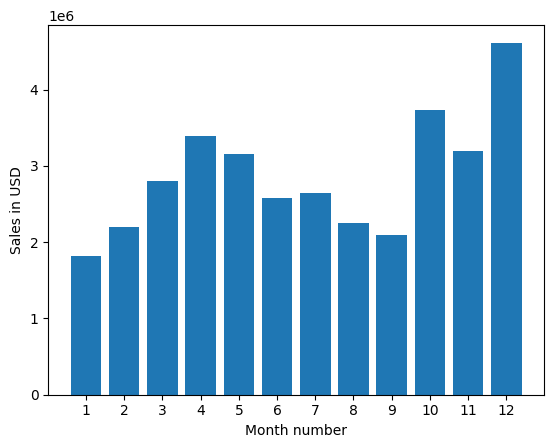

In [28]:

months=range(1,13)
plt.bar(months,all_data.groupby('Month')['Sales'].sum())
plt.xticks(months)
plt.ylabel('Sales in USD')
plt.xlabel('Month number')
plt.show()


In [30]:
#dans quelle ville nous avons enregistré un maximum de commandes
'669 2nd St, New York City, NY 10001'.split(',')[1]

' New York City'

In [31]:
def city(x):
  return x.split(',')[1]

In [32]:
all_data["city"]=all_data['Purchase Address'].apply(city)
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,Month,Sales,city
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",05,5,11.99,New York City
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",05,5,3.84,Dallas
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",05,5,149.99,New York City
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",05,5,11.99,Dallas
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",05,5,5.98,Seattle
...,...,...,...,...,...,...,...,...,...,...
186845,222905,AAA Batteries (4-pack),1,2.99,06/07/19 19:02,"795 Pine St, Boston, MA 02215",06,6,2.99,Boston
186846,222906,27in FHD Monitor,1,149.99,06/01/19 19:29,"495 North St, New York City, NY 10001",06,6,149.99,New York City
186847,222907,USB-C Charging Cable,1,11.95,06/22/19 18:57,"319 Ridge St, San Francisco, CA 94016",06,6,11.95,San Francisco
186848,222908,USB-C Charging Cable,1,11.95,06/26/19 18:35,"916 Main St, San Francisco, CA 94016",06,6,11.95,San Francisco


In [33]:
all_data.groupby('city')['city'].count()

,city
city,
Atlanta,14881
Austin,9905
Boston,19934
Dallas,14820
Los Angeles,29605
New York City,24876
Portland,12465
San Francisco,44732
Seattle,14732


In [36]:
all_data.groupby('city')['city'].count().index


Index([' Atlanta', ' Austin', ' Boston', ' Dallas', ' Los Angeles',
       ' New York City', ' Portland', ' San Francisco', ' Seattle'],
      dtype='object', name='city')

In [37]:
all_data.groupby('city')['city'].count().values

array([14881,  9905, 19934, 14820, 29605, 24876, 12465, 44732, 14732])

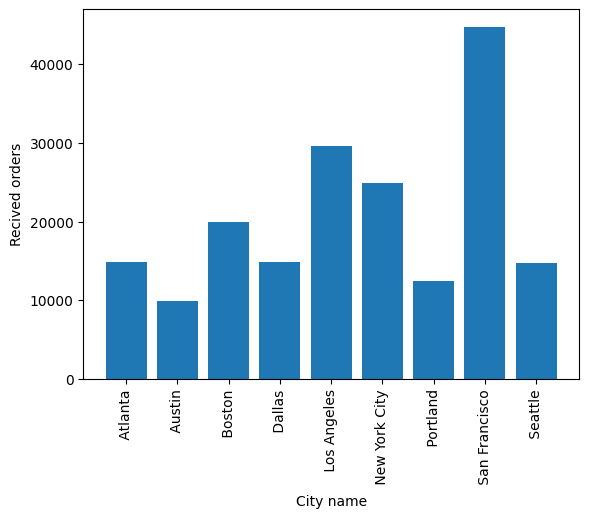

In [38]:

plt.bar(all_data.groupby('city')['city'].count().index,all_data.groupby('city')['city'].count())
plt.xticks(rotation='vertical')
plt.ylabel('Recived orders')
plt.xlabel('City name')
plt.show()

In [40]:
#en quelle moment doit on fiare un ecompagne publicitaire pour avoir plus de ventes
all_data['Hour']=pd.to_datetime(all_data['Order Date']).dt.hour
all_data

/tmp/ipython-input-1247271127.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Hour']=pd.to_datetime(all_data['Order Date']).dt.hour


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,Month,Sales,city,Hour
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",05,5,11.99,New York City,17
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",05,5,3.84,Dallas,14
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",05,5,149.99,New York City,11
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",05,5,11.99,Dallas,20
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",05,5,5.98,Seattle,22
...,...,...,...,...,...,...,...,...,...,...,...
186845,222905,AAA Batteries (4-pack),1,2.99,06/07/19 19:02,"795 Pine St, Boston, MA 02215",06,6,2.99,Boston,19
186846,222906,27in FHD Monitor,1,149.99,06/01/19 19:29,"495 North St, New York City, NY 10001",06,6,149.99,New York City,19
186847,222907,USB-C Charging Cable,1,11.95,06/22/19 18:57,"319 Ridge St, San Francisco, CA 94016",06,6,11.95,San Francisco,18
186848,222908,USB-C Charging Cable,1,11.95,06/26/19 18:35,"916 Main St, San Francisco, CA 94016",06,6,11.95,San Francisco,18


In [42]:
keys=[]
hours=[]
for key,hour in all_data.groupby('Hour'):
  keys.append(key)
  hours.append(len(hour))
hours

[3910,
 2350,
 1243,
 831,
 854,
 1321,
 2482,
 4011,
 6256,
 8748,
 10944,
 12411,
 12587,
 12129,
 10984,
 10175,
 10384,
 10899,
 12280,
 12905,
 12228,
 10921,
 8822,
 6275]

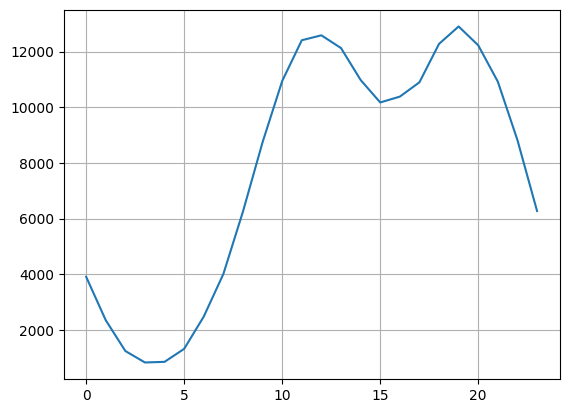

In [43]:
plt.grid()
plt.plot(keys,hours)
plt.xlabel('heure de la journée')
plt.xlabel('nombre des commandes')


<Axes: xlabel='Product'>

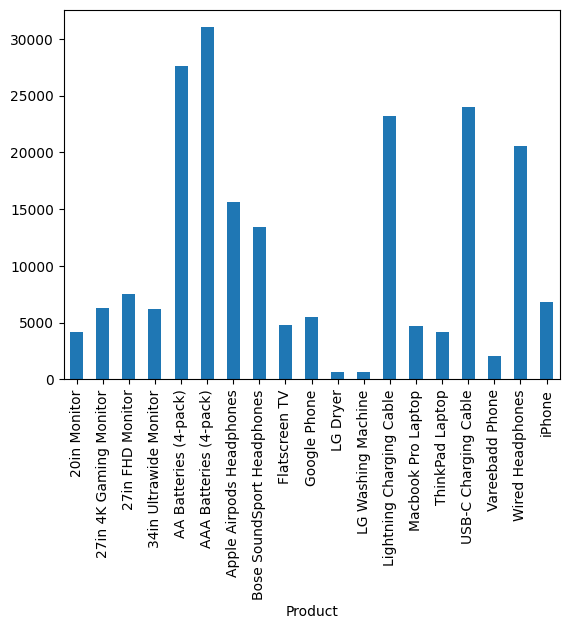

In [46]:
#quel produit se vend le plus ?
all_data.groupby('Product')['Quantity Ordered'].sum().plot(kind='bar')

In [47]:
all_data.groupby('Product')['Price Each'].mean()

,Price Each
Product,
20in Monitor,109.99
27in 4K Gaming Monitor,389.99
27in FHD Monitor,149.99
34in Ultrawide Monitor,379.99
AA Batteries (4-pack),3.84
AAA Batteries (4-pack),2.99
Apple Airpods Headphones,150.00
Bose SoundSport Headphones,99.99
Flatscreen TV,300.00


In [49]:
products=all_data.groupby('Product')['Quantity Ordered'].sum().index
quantity=all_data.groupby('Product')['Quantity Ordered'].sum()
prices=all_data.groupby('Product')['Price Each'].mean()


/tmp/ipython-input-999167276.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(products, rotation='vertical', fontsize=8)


[Text(0, 0, '20in Monitor'),
 Text(1, 0, '27in 4K Gaming Monitor'),
 Text(2, 0, '27in FHD Monitor'),
 Text(3, 0, '34in Ultrawide Monitor'),
 Text(4, 0, 'AA Batteries (4-pack)'),
 Text(5, 0, 'AAA Batteries (4-pack)'),
 Text(6, 0, 'Apple Airpods Headphones'),
 Text(7, 0, 'Bose SoundSport Headphones'),
 Text(8, 0, 'Flatscreen TV'),
 Text(9, 0, 'Google Phone'),
 Text(10, 0, 'LG Dryer'),
 Text(11, 0, 'LG Washing Machine'),
 Text(12, 0, 'Lightning Charging Cable'),
 Text(13, 0, 'Macbook Pro Laptop'),
 Text(14, 0, 'ThinkPad Laptop'),
 Text(15, 0, 'USB-C Charging Cable'),
 Text(16, 0, 'Vareebadd Phone'),
 Text(17, 0, 'Wired Headphones'),
 Text(18, 0, 'iPhone')]

<Figure size 4000x2400 with 0 Axes>

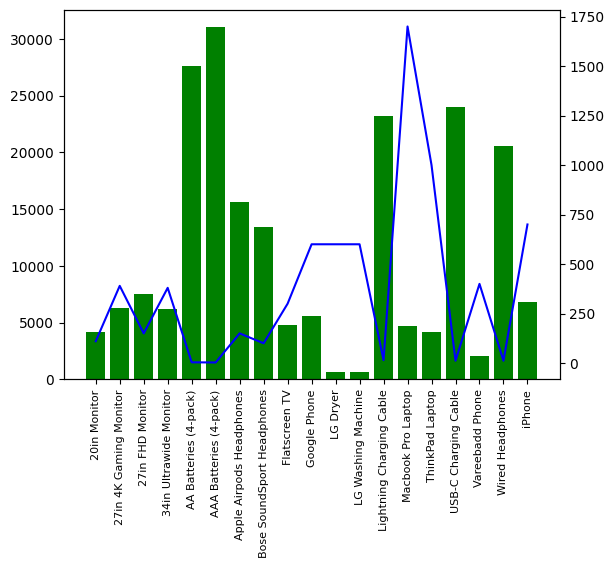

In [55]:
plt.figure(figsize=(40,24))
fig,ax1=plt.subplots()
ax2=ax1.twinx()
ax1.bar(products,quantity,color='g')
ax2.plot(products,prices,'b-')
ax1.set_xticklabels(products, rotation='vertical', fontsize=8)


In [58]:
#quelles sont les combinaisons de produits qui se vendent le plus?
df=all_data[all_data['Order ID'].duplicated(keep=False)]


In [59]:
df['Grouped']=df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df

/tmp/ipython-input-2869374375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grouped']=df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,Month,Sales,city,Hour,Grouped
15,194110,Google Phone,1,600.00,05/31/19 18:07,"498 14th St, Los Angeles, CA 90001",05,5,600.00,Los Angeles,18,"Google Phone,Wired Headphones"
16,194110,Wired Headphones,1,11.99,05/31/19 18:07,"498 14th St, Los Angeles, CA 90001",05,5,11.99,Los Angeles,18,"Google Phone,Wired Headphones"
77,194170,Google Phone,1,600.00,05/30/19 12:30,"711 Maple St, San Francisco, CA 94016",05,5,600.00,San Francisco,12,"Google Phone,USB-C Charging Cable"
78,194170,USB-C Charging Cable,2,11.95,05/30/19 12:30,"711 Maple St, San Francisco, CA 94016",05,5,23.90,San Francisco,12,"Google Phone,USB-C Charging Cable"
82,194174,iPhone,1,700.00,05/04/19 23:08,"37 North St, Seattle, WA 98101",05,5,700.00,Seattle,23,"iPhone,Lightning Charging Cable,Wired Headphones"
...,...,...,...,...,...,...,...,...,...,...,...,...
186820,222882,AA Batteries (4-pack),1,3.84,06/18/19 11:37,"990 Walnut St, Los Angeles, CA 90001",06,6,3.84,Los Angeles,11,"Apple Airpods Headphones,AA Batteries (4-pack)"
186822,222884,Google Phone,1,600.00,06/04/19 12:06,"819 Pine St, New York City, NY 10001",06,6,600.00,New York City,12,"Google Phone,USB-C Charging Cable"
186823,222884,USB-C Charging Cable,1,11.95,06/04/19 12:06,"819 Pine St, New York City, NY 10001",06,6,11.95,New York City,12,"Google Phone,USB-C Charging Cable"
186842,222903,iPhone,1,700.00,06/07/19 22:21,"685 Hickory St, New York City, NY 10001",06,6,700.00,New York City,22,"iPhone,Lightning Charging Cable"


In [60]:
df['Grouped']

,Grouped
15,"Google Phone,Wired Headphones"
16,"Google Phone,Wired Headphones"
77,"Google Phone,USB-C Charging Cable"
78,"Google Phone,USB-C Charging Cable"
82,"iPhone,Lightning Charging Cable,Wired Headphones"
...,...
186820,"Apple Airpods Headphones,AA Batteries (4-pack)"
186822,"Google Phone,USB-C Charging Cable"
186823,"Google Phone,USB-C Charging Cable"
186842,"iPhone,Lightning Charging Cable"


In [61]:
df2=df.drop_duplicates(subset=['Order ID'])
df2

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,Month,Sales,city,Hour,Grouped
15,194110,Google Phone,1,600.00,05/31/19 18:07,"498 14th St, Los Angeles, CA 90001",05,5,600.00,Los Angeles,18,"Google Phone,Wired Headphones"
77,194170,Google Phone,1,600.00,05/30/19 12:30,"711 Maple St, San Francisco, CA 94016",05,5,600.00,San Francisco,12,"Google Phone,USB-C Charging Cable"
82,194174,iPhone,1,700.00,05/04/19 23:08,"37 North St, Seattle, WA 98101",05,5,700.00,Seattle,23,"iPhone,Lightning Charging Cable,Wired Headphones"
89,194179,Flatscreen TV,1,300.00,05/10/19 22:51,"143 Spruce St, Boston, MA 02215",05,5,300.00,Boston,22,"Flatscreen TV,AAA Batteries (4-pack)"
103,194192,Wired Headphones,1,11.99,05/14/19 18:00,"137 Jackson St, San Francisco, CA 94016",05,5,11.99,San Francisco,18,"Wired Headphones,Bose SoundSport Headphones"
...,...,...,...,...,...,...,...,...,...,...,...,...
186798,222863,27in FHD Monitor,1,149.99,06/07/19 11:05,"222 Walnut St, Austin, TX 73301",06,6,149.99,Austin,11,"27in FHD Monitor,Bose SoundSport Headphones"
186804,222868,iPhone,1,700.00,06/16/19 13:53,"505 North St, New York City, NY 10001",06,6,700.00,New York City,13,"iPhone,Apple Airpods Headphones"
186819,222882,Apple Airpods Headphones,1,150.00,06/18/19 11:37,"990 Walnut St, Los Angeles, CA 90001",06,6,150.00,Los Angeles,11,"Apple Airpods Headphones,AA Batteries (4-pack)"
186822,222884,Google Phone,1,600.00,06/04/19 12:06,"819 Pine St, New York City, NY 10001",06,6,600.00,New York City,12,"Google Phone,USB-C Charging Cable"


<Axes: ylabel='count'>

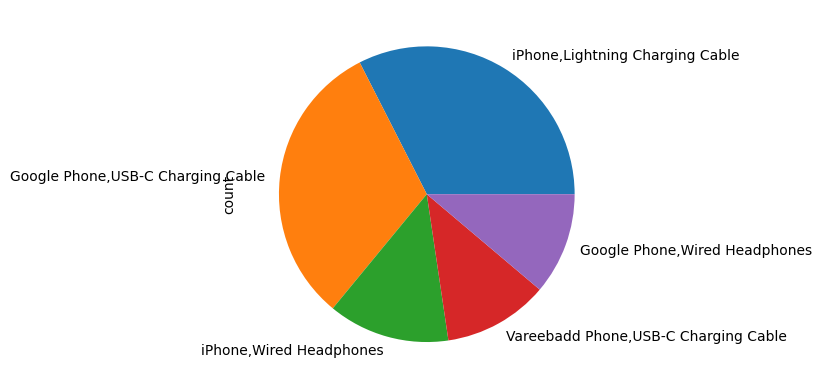

In [63]:
df2['Grouped'].value_counts()[0:5].plot.pie()